In [11]:
import torch
from typing import Callable
import matplotlib.pyplot as plt
import random
import numpy as np
import os
import matplotlib

# Matrices

In [12]:
class ConfusionMatrix:
    def __init__(self, method: str, C: int):
        self.C = C

        methods: dict[str, Callable[[torch.Tensor, torch.Tensor], torch.Tensor]] = {
            "CM": self.CM,
            "TCM": self.TCM,
            "TCM_lab": self.TCM_lab,
            "TCM_invert_lab": self.TCM_invert_lab,
            "TCM_pred": self.TCM_pred,
            "MLCM": self.MLCM,
            "SCM": self.SCM,
            "SCM_min": self.SCM_min,
            "SCM_max": self.SCM_max,
            "MLCTr": self.MLCT_R,
            "MLCTp": self.MLCT_P,
        }

        if method not in methods:
            valid = ", ".join(methods.keys())
            raise ValueError(f"Unknown method '{method}'. Valid methods are: {valid}")

        self.elementary_matrix = methods[method]

    @staticmethod
    def _validate_vectors(label: torch.Tensor, pred: torch.Tensor) -> None:
        if not isinstance(label, torch.Tensor) or not isinstance(pred, torch.Tensor):
            raise TypeError("label and pred must be torch tensors.")
        if label.ndim != 1 or pred.ndim != 1:
            raise ValueError("label and pred must be 1D tensors.")
        if label.shape != pred.shape:
            raise ValueError("label and pred must have the same shape.")
        if label.dtype not in (torch.float32, torch.float64):
            raise TypeError("label must have dtype torch.float32 or torch.float64.")
        if pred.dtype not in (torch.float32, torch.float64):
            raise TypeError("pred must have dtype torch.float32 or torch.float64.")
        if not torch.all(label >= 0):
            raise ValueError("label must contain only non-negative values.")
        if not torch.all(pred >= 0):
            raise ValueError("pred must contain only non-negative values.")

    @staticmethod
    def _normalize(vec: torch.Tensor, name: str) -> torch.Tensor:
        total = vec.sum()
        if total <= 0:
            raise ValueError(f"{name} must have a strictly positive sum.")
        return vec / total

    def TCM(self, label: torch.Tensor, pred: torch.Tensor) -> torch.Tensor:
        """
        Build the elementary transport/confusion matrix associated with
        two non-negative vectors label and pred.
        """
        label = self._normalize(label, "label")
        pred = self._normalize(pred, "pred")

        overlap = torch.minimum(label, pred)
        diag_mat = torch.diag(overlap)

        if torch.allclose(label, pred):
            return diag_mat

        under = label - overlap
        over = pred - overlap
        residual_mass = under.sum()

        if residual_mass <= 1e-12:
            return diag_mat

        off_diag = torch.outer(under, over) / residual_mass
        return diag_mat + off_diag

    def TCM_lab(self, label: torch.Tensor, pred: torch.Tensor) -> torch.Tensor:
        return label.sum() * self.TCM(label, pred)

    def TCM_invert_lab(self, label: torch.Tensor, pred: torch.Tensor) -> torch.Tensor:
        return self.TCM(label, pred) / label.sum()

    def TCM_pred(self, label: torch.Tensor, pred: torch.Tensor) -> torch.Tensor:
        return pred.sum() * self.TCM(label, pred)

    def CM(self, label: torch.Tensor, pred: torch.Tensor) -> torch.Tensor:
        label = self._normalize(label, "label")
        pred = self._normalize(pred, "pred")
        return torch.outer(label, pred)
    
    def MLCM(self, label, pred):
        min = torch.minimum(label, pred)
    
        if torch.equal(label, pred):
            return torch.diag(label)
        elif torch.all(label - min == 0):
            return torch.outer(label, pred - min) / pred.sum() + torch.diag(label) * label.sum() / pred.sum()
        elif torch.all(pred - min == 0):
            return torch.outer(label - min, pred) / pred.sum() + torch.diag(pred)
        else:
            return torch.outer(label - min, pred - min) / (pred - min).sum() + torch.diag(min)

    def MLCT_R(self, label: torch.Tensor, pred: torch.Tensor) -> torch.Tensor:
        overlap = torch.minimum(label, pred)
        pred_sum = pred.sum()
        if pred_sum <= 0:
            raise ValueError("pred must have a strictly positive sum.")

        return torch.diag(overlap) + torch.outer(label - overlap, pred) / pred_sum

    def MLCT_P(self, label: torch.Tensor, pred: torch.Tensor) -> torch.Tensor:
        overlap = torch.minimum(label, pred)
        label_sum = label.sum()
        if label_sum <= 0:
            raise ValueError("label must have a strictly positive sum.")

        return torch.diag(overlap) + torch.outer(label, pred - overlap) / label_sum

    def SCM_max(self, label: torch.Tensor, pred: torch.Tensor) -> torch.Tensor:
        label = self._normalize(label, "label")
        pred = self._normalize(pred, "pred")

        overlap = torch.minimum(label, pred)
        r_prime = label - overlap
        s_prime = pred - overlap

        r_mat = r_prime.unsqueeze(1).expand(self.C, self.C)
        s_mat = s_prime.unsqueeze(0).expand(self.C, self.C)

        return torch.diag(overlap) + torch.minimum(r_mat, s_mat)

    def SCM_min(self, label: torch.Tensor, pred: torch.Tensor) -> torch.Tensor:
        label = self._normalize(label, "label")
        pred = self._normalize(pred, "pred")

        overlap = torch.minimum(label, pred)
        r_prime = label - overlap
        s_prime = pred - overlap

        r_mat = r_prime.unsqueeze(1).expand(self.C, self.C)
        s_mat = s_prime.unsqueeze(0).expand(self.C, self.C)

        out = torch.maximum(
            r_mat + s_mat - s_prime.sum(),
            torch.zeros((self.C, self.C), dtype=label.dtype, device=label.device),
        )
        out.fill_diagonal_(0)

        return torch.diag(overlap) + out

    def SCM(self, label: torch.Tensor, pred: torch.Tensor) -> torch.Tensor:
        return 0.5 * (self.SCM_min(label, pred) + self.SCM_max(label, pred))

    def __call__(self, labels: torch.Tensor, predictions: torch.Tensor) -> torch.Tensor:
        mat = torch.zeros((self.C, self.C), dtype=labels.dtype, device=labels.device)

        for label, prediction in zip(labels, predictions):
            self._validate_vectors(label, prediction)
            mat += self.elementary_matrix(label, prediction)

        return mat

# Ground-truth

In [13]:
def sample_theoretical_row(row_index, num_classes, max_modes, alpha):
    num_active_modes = np.random.randint(1, max_modes + 1)

    row = np.zeros(num_classes)

    for _ in range(num_active_modes):
        alpha = np.full(num_classes, alpha)
        row += np.random.dirichlet(alpha)

    row /= num_active_modes

    # --- Swap: put dominant value on the diagonal position ---
    max_index = np.argmax(row)

    row[row_index], row[max_index] = row[max_index], row[row_index]

    return row


def theoretical_confusion_matrix(C: int, alpha: float, n: int):
    num_classes = C
    max_modes = n
    """
    Sample a num_classes x num_classes theoretical matrix.

    Each row is generated independently, with its maximum placed on the diagonal.
    """
    rows = [
        sample_theoretical_row(
            row_index=i,
            num_classes=num_classes,
            max_modes=max_modes,
            alpha=alpha
        )
        for i in range(num_classes)
    ]

    return torch.tensor(np.vstack(rows))

# Label-prediction pairs

In [14]:
def sample_label(C: int, max_classes: int, soft) -> torch.Tensor:
    """
    Sample a random non-empty binary label vector of size C.

    The number of active classes is drawn uniformly in {1, ..., max_classes},
    then the active positions are selected uniformly without replacement.

    Args:
        C: Total number of classes.
        max_classes: Maximum number of active classes.

    Returns:
        A tensor of shape (C,) with entries in {0., 1.}, containing
        at least one active class.
    """
    if not isinstance(C, int) or C <= 0:
        raise ValueError("C must be a strictly positive integer.")
    if not isinstance(max_classes, int) or max_classes <= 0:
        raise ValueError("max_classes must be a strictly positive integer.")
    if max_classes > C:
        raise ValueError("max_classes must be smaller than or equal to C.")

    num_active = torch.randint(1, max_classes + 1, (1,)).item()
    active_indices = torch.randperm(C)[:num_active]

    label = torch.zeros(C, dtype=torch.float32)
    
    if soft:
        label[active_indices] = .1 + torch.rand(num_active)*.9
    else:
        label[active_indices] = 1.0
        
    return label


def sample_prediction(
    label: torch.Tensor,
    confusion_matrix: torch.Tensor,
    soft
) -> torch.Tensor:
    """
    Sample a non-empty binary prediction vector from a non-empty binary label vector.

    For each active true class, one predicted class is sampled according to the
    corresponding row of the confusion matrix. The final prediction is the union
    of all sampled predicted classes.

    Args:
        label: Binary tensor of shape (C,).
        confusion_matrix: Tensor of shape (C, C), where row i defines a
            probability distribution for predictions conditioned on class i.

    Returns:
        A binary tensor of shape (C,) with at least one active class.
    """
    if label.ndim != 1:
        raise ValueError("label must be a 1D tensor.")
    if confusion_matrix.ndim != 2:
        raise ValueError("confusion_matrix must be a 2D tensor.")
    if confusion_matrix.shape[0] != confusion_matrix.shape[1]:
        raise ValueError("confusion_matrix must be square.")
    if confusion_matrix.shape[0] != label.numel():
        raise ValueError("label and confusion_matrix must have compatible shapes.")

    active_labels = torch.where(label > 0)[0]
    if active_labels.numel() == 0:
        raise ValueError("label must contain at least one active class.")

    prediction = torch.zeros_like(label)
    
    if soft:
        granularity = 0.1
    
        for true_class in active_labels:
            class_distribution = confusion_matrix[true_class]
    
            n_samples = int(label[true_class].item() / granularity)
    
            predicted_classes = torch.multinomial(
                class_distribution,
                num_samples=n_samples,
                replacement=True,
            )
    
            prediction.scatter_add_(
                dim=0,
                index=predicted_classes,
                src=torch.full(
                    (n_samples,),
                    granularity,
                    dtype=prediction.dtype,
                    device=prediction.device,
                ),
            )
    
    else:
        for true_class in active_labels:
            class_distribution = confusion_matrix[true_class]
    
            predicted_class = torch.multinomial(
                class_distribution,
                num_samples=1,
            ).item()
    
            prediction[predicted_class] = 1.0

    if prediction.sum() == 0:
        raise RuntimeError("Prediction sampling produced an empty prediction.")

    return prediction


def random_zero_mask_non_empty(x: torch.Tensor, p: float) -> torch.Tensor:
    """
    Randomly mask entries of x with probability p, while guaranteeing that
    at least one originally active entry remains active.

    Args:
        x: Binary tensor.
        p: Probability of masking each entry.

    Returns:
        A tensor of the same shape as x, with at least one positive entry
        if x originally contained at least one positive entry.
    """
    if not (0.0 <= p < 1.0):
        raise ValueError("p must satisfy 0 <= p < 1.")

    active_indices = torch.where(x > 0)[0]
    if active_indices.numel() == 0:
        raise ValueError("x must contain at least one active entry.")

    while True:
        mask = (torch.rand_like(x) > p).to(x.dtype)
        y = x * mask
        if y.sum() > 0:
            return y


def generate_synthetic_dataset(
    N: int,
    C: int,
    confusion_matrix: torch.Tensor,
    max_classes: int,
    drop_out: float,
    soft,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Generate a synthetic multilabel dataset with no empty label and no empty prediction.

    Args:
        N: Number of samples.
        C: Number of classes.
        confusion_matrix: Tensor of shape (C, C).
        max_classes: Maximum number of active classes in each label.
        p: Probability of masking each entry.

    Returns:
        A pair (labels, predictions), each of shape (N, C).
    """
    if not isinstance(N, int) or N <= 0:
        raise ValueError("N must be a strictly positive integer.")
    if not isinstance(C, int) or C <= 0:
        raise ValueError("C must be a strictly positive integer.")
    if confusion_matrix.shape != (C, C):
        raise ValueError("confusion_matrix must have shape (C, C).")

    labels = []
    predictions = []

    for i in range(N):
        label = sample_label(C, max_classes, soft=soft)
        prediction = sample_prediction(label, confusion_matrix, soft=soft)

        if i%2==0:
            label = random_zero_mask_non_empty(label, drop_out)
        else:
            prediction = random_zero_mask_non_empty(prediction, drop_out)
        
        labels.append(label)
        predictions.append(prediction)

    return torch.stack(labels), torch.stack(predictions)

# Compute global

In [15]:
def precompute_synthetic_matrices(
    alpha,
    methods,
    C,
    n_modes,
    N=100,
    n_runs=5,
    max_classes=None,
    soft=False,
):
    """
    Pré-calcule et stocke toutes les matrices nécessaires.

    Structure retournée :
    storage[n_modes_val][C_val] = {
        "theoretical_cm": theoretical_cm,
        "empirical_cms": {
            method_name: [cm_run1, cm_run2, ..., cm_runN]
        }
    }
    """
    method_names = [str(m) for m in methods]
    storage = {}

    for n_modes_val in n_modes:
        storage[n_modes_val] = {}

        for C_val in C:
            if max_classes is None:
                max_classes_val = int(C_val/2)
            else:
                max_classes_val = max_classes

            drop_out = .25

            theoretical_cm = theoretical_confusion_matrix(
                C_val, alpha, n_modes_val
            )

            empirical_cms = {method_name: [] for method_name in method_names}

            for _ in range(n_runs):
                labels, predictions = generate_synthetic_dataset(
                    N,
                    C_val,
                    theoretical_cm,
                    max_classes_val,
                    drop_out, 
                    soft=soft
                )

                for method, method_name in zip(methods, method_names):
                    cm = ConfusionMatrix(method, C_val)
                    empirical_cm = cm(labels, predictions)

                    empirical_cm = empirical_cm / empirical_cm.sum(
                        dim=1, keepdim=True
                    ).clamp_min(1e-12)

                    empirical_cms[method_name].append(empirical_cm.detach().clone())

            storage[n_modes_val][C_val] = {
                "theoretical_cm": theoretical_cm.detach().clone()
                if isinstance(theoretical_cm, torch.Tensor)
                else theoretical_cm,
                "empirical_cms": empirical_cms,
            }

    return storage


def compute_scores_from_storage(storage, score_fns, methods):
    """
    Calcule mean/std de chaque score à partir des matrices déjà stockées.

    Retour :
    results[score_name][n_modes_val][method_name] = {
        "mean": [...],
        "std": [...]
    }
    """
    method_names = [str(m) for m in methods]
    results = {}

    for score_name, score_fn in score_fns.items():
        results[score_name] = {}

        for n_modes_val, data_by_C in storage.items():
            results[score_name][n_modes_val] = {}

            C_values = sorted(data_by_C.keys())

            for method_name in method_names:
                means = []
                stds = []

                for C_val in C_values:
                    theoretical_cm = data_by_C[C_val]["theoretical_cm"]
                    empirical_cms = data_by_C[C_val]["empirical_cms"][method_name]

                    vals = []
                    for empirical_cm in empirical_cms:
                        val = score_fn(empirical_cm, theoretical_cm)

                        if isinstance(val, torch.Tensor):
                            val = val.item()

                        vals.append(val)

                    vals = np.array(vals)
                    means.append(vals.mean())
                    stds.append(vals.std())

                results[score_name][n_modes_val][method_name] = {
                    "mean": means,
                    "std": stds,
                }

    return results


# Scores

In [16]:
def normalize(M1, M2):
    m1 = M1/M1.sum(dim=1, keepdim=True)
    m1 = m1/m1.sum()
    m2 = M2/M2.sum(dim=1, keepdim=True)
    m2 = m2/m2.sum()
    return m1, m2

def overlap(M1, M2):
    m1, m2 = normalize(M1, M2)
    return torch.minimum(m1,m2).sum().item()

def kl_divergence(M1: torch.Tensor, M2: torch.Tensor):
    """
    KL(C1 || C2) sur matrices aplaties (normalisées en distributions).
    """
    M1, M2 = normalize(M1, M2)
    M1 = M1.flatten().float()
    M2 = M2.flatten().float()
    mask = M1>0
    return (M1[mask] * torch.log(M1[mask] / M2[mask])).sum()

def jensen_shannon_divergence(M1, M2):
    M1 = M1 /M1.sum(dim=1, keepdim=True)
    M2 = M2 /M2.sum(dim=1, keepdim=True)

    M = 0.5 * (M1 + M2)

    return 0.5 * kl_divergence(M1, M) + 0.5 * kl_divergence(M2, M)

# Plots

In [47]:
def ax_plot(ax, x, y, std, color, label, marker='.', markersize=3, linewidth=1):
    y = np.array(y)
    std = np.array(std)

    ax.plot(
        x, y,
        marker=marker,
        color=color,
        label=label,
        markersize=markersize,
        linewidth=linewidth
    )
    ax.fill_between(x, y - std, y + std, color=color, alpha=0.1)

def plot_scores_from_results(
    results,
    methods,
    C,
    n_modes,
    alpha,
    save_path=None,
):
    """
    Trace les figures à partir des résultats déjà calculés.
    """
    method_names = [str(m) for m in methods]
    score_names = list(results.keys())

    cmap = matplotlib.colormaps['tab10']
    colors = [cmap(i) for i in range(len(methods))]

    for score_name in score_names:
        fig, axes = plt.subplots(
            1,
            len(n_modes),
            figsize=(2 * len(n_modes), 3),
            sharey=True
        )

        if len(n_modes) == 1:
            axes = [axes]

        for j, n_modes_val in enumerate(n_modes):
            ax = axes[j]

            for k, method_name in enumerate(method_names):
                ax_plot(
                    ax,
                    x=C,
                    y=results[score_name][n_modes_val][method_name]["mean"],
                    std=results[score_name][n_modes_val][method_name]["std"],
                    color=colors[k],
                    label=method_name,
                    marker='o'
                )

            ax.set_title(f"Max samples={n_modes_val}", fontsize=12)
            ax.set_xlabel("C", fontsize=14)
            ax.set_xticks(C)
            ax.tick_params(axis='y', labelsize=12)
            ax.tick_params(axis='x', labelsize=12)
            ax.grid(alpha=0.2)

            if j == 0:
                ax.set_ylabel(score_name, fontsize=14)

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            loc="upper center",
            ncol=len(methods),
            bbox_to_anchor=(0.5, 1.1)
        )
        plt.tight_layout()

        if save_path is not None:
            base, ext = os.path.splitext(save_path)
            path = f"{base}_{score_name}{ext}"
            dirpath = os.path.dirname(path)
            if dirpath:
                os.makedirs(dirpath, exist_ok=True)
            plt.savefig(path, dpi=300, bbox_inches="tight")

        plt.show()


def plot_synthetic_scores(
    alpha,
    methods,
    score_fns,
    C,
    n_modes,
    N=100,
    n_runs=5,
    max_classes=None,
    save_path=None,
    plot_heatmaps=True,
    C_heatmap=20,
    soft=False,
):
    """
    Pipeline complet :
    1. pré-calcul des matrices
    2. calcul des scores
    3. tracé des courbes
    4. tracé des heatmaps théoriques en taille 20
    """
    storage = precompute_synthetic_matrices(
        alpha=alpha,
        methods=methods,
        C=C,
        n_modes=n_modes,
        N=N,
        n_runs=n_runs,
        max_classes=max_classes,
        soft=soft
    )

    results = compute_scores_from_storage(
        storage=storage,
        score_fns=score_fns,
        methods=methods,
    )

    plot_scores_from_results(
        results=results,
        methods=methods,
        C=C,
        n_modes=n_modes,
        alpha=alpha,
        save_path=save_path,
    )


def plot_theoretical_heatmaps(
    alpha,
    n_modes,
    C_heatmap=20,
    save_path=None,
):
    """
    Trace une heatmap par couple (alpha, n_modes)
    -> une ligne par alpha
    -> une colonne par n_modes
    """

    n_alpha = len(alpha)
    n_modes_len = len(n_modes)

    fig, axes = plt.subplots(
        n_alpha,
        n_modes_len,
        figsize=(2 * n_modes_len, 2 * n_alpha)
    )

    # ensure 2D axes
    if n_alpha == 1:
        axes = [axes]
    if n_modes_len == 1:
        axes = [[ax] for ax in axes]

    # --- calcul des matrices ---
    matrices = []
    for alpha_val in alpha:
        row = []
        for n_modes_val in n_modes:
            cm = theoretical_confusion_matrix(C_heatmap, alpha_val, n_modes_val)
            if isinstance(cm, torch.Tensor):
                cm = cm.detach().cpu().numpy()
            row.append(cm)
        matrices.append(row)

    # --- échelle commune ---
    vmin = min(mat.min() for row in matrices for mat in row)
    vmax = max(mat.max() for row in matrices for mat in row)

    # --- plot ---
    for i, alpha_val in enumerate(alpha):
        for j, n_modes_val in enumerate(n_modes):
            ax = axes[i][j]
            cm = matrices[i][j]

            im = ax.imshow(
                cm,
                cmap="magma",
                aspect="auto",
                vmin=vmin,
                vmax=vmax
            )

            if i == 0:
                ax.set_title(f"Max samples={n_modes_val}", fontsize=12)

            if j == 0:
                ax.set_ylabel(f"alpha={alpha_val}", fontsize=12)

            ax.set_xticks([])
            ax.set_yticks([])

    # --- colorbar ---
    fig.subplots_adjust(right=0.88)
    cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=11)

    # --- save ---
    if save_path is not None:
        base, ext = os.path.splitext(save_path)
        path = f"{base}_theoretical_heatmaps_C{C_heatmap}{ext}"
        dirpath = os.path.dirname(path)
        if dirpath:
            os.makedirs(dirpath, exist_ok=True)
        plt.savefig(path, dpi=300, bbox_inches="tight")

    plt.show()

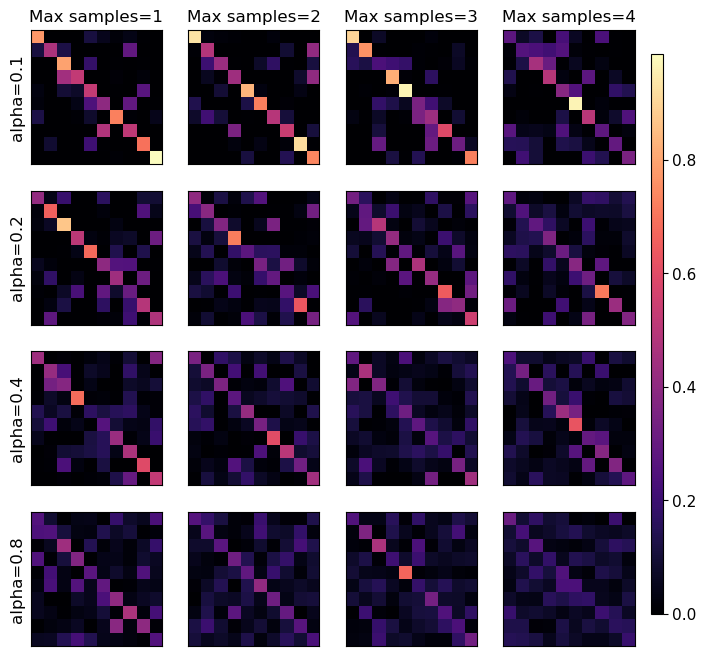

In [52]:
n_modes = [1, 2, 3, 4]
alphas = [.1, .2, .4, .8]
C_heatmap = 10
plot_theoretical_heatmaps(
                alpha=alphas,
                n_modes=n_modes,
                C_heatmap=C_heatmap,
                save_path="plots/synthetic_scores.png",
            )

In [25]:
score_fns = {
    "Overlap": overlap,
    "JSD": jensen_shannon_divergence
}

alphas = [.1, .2, .4, .8]
n_modes = [1, 2, 3, 4]
C=[10, 20, 30, 40, 50]
N= 15000
n_runs= 5
max_classes = 10

for soft in [False, True]:
    if soft:
        methods = ['TCM', 'TCM_invert_lab', 'SCM', 'SCM_max', 'SCM_min']
    else:
        methods = ['TCM', 'TCM_invert_lab', 'SCM', 'SCM_max', 'SCM_min', 'MLCM', 'MLCTr', 'MLCTp']
    
    for alpha in alphas:
        print("alpha:", alpha)
        print("soft:", soft)
        
        name = "plots/synthetic_scores_"+str(alpha)+str(soft)+".png"
        plot_synthetic_scores(
            alpha=alpha,
            methods=methods,
            score_fns=score_fns,
            C=C,
            N= N,
            n_modes=n_modes,
            n_runs=n_runs,
            max_classes = max_classes,
            save_path=name,
            soft=False
        )

alpha: 0.1
soft: False



KeyboardInterrupt


KeyboardInterrupt



alpha: 0.1
soft: False
ERROR! Session/line number was not unique in database. History logging moved to new session 5129


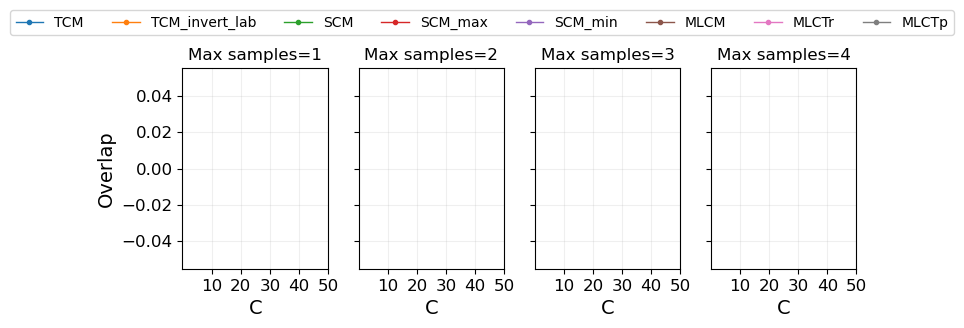

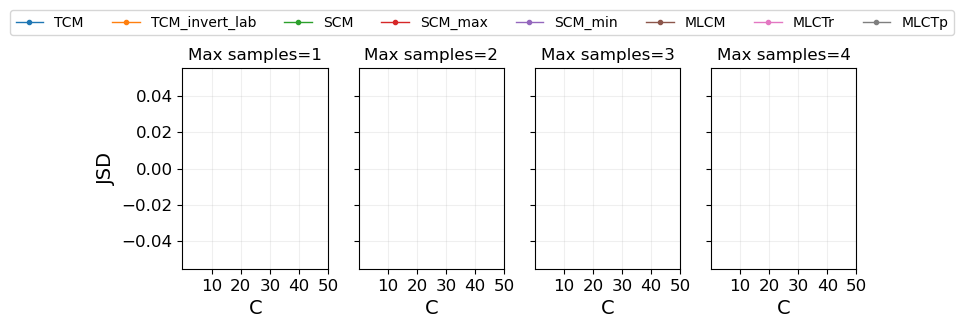

alpha: 0.2
soft: False


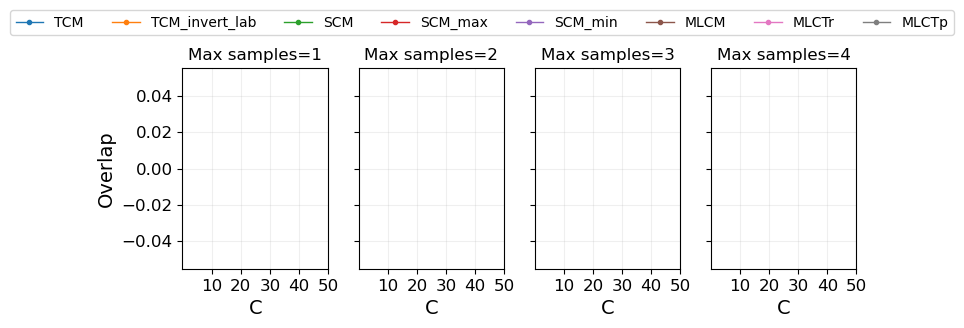

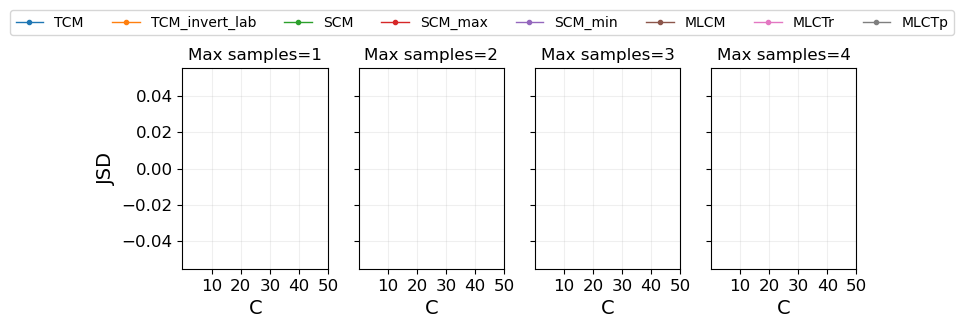

alpha: 0.4
soft: False


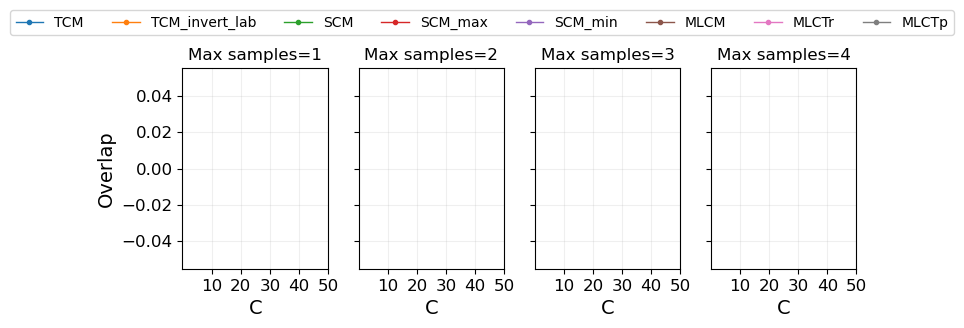

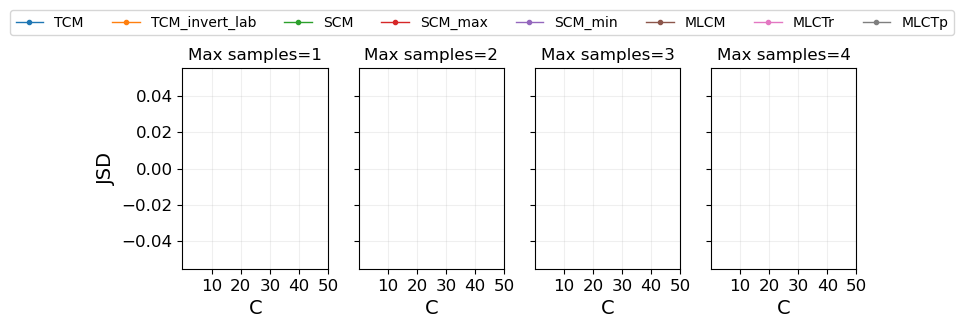

alpha: 0.8
soft: False


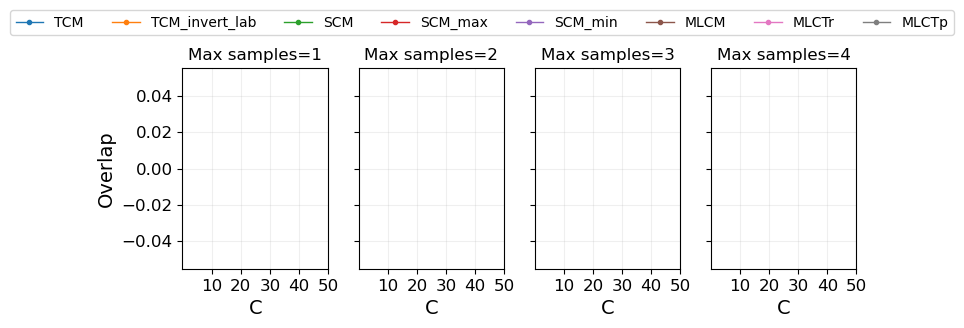

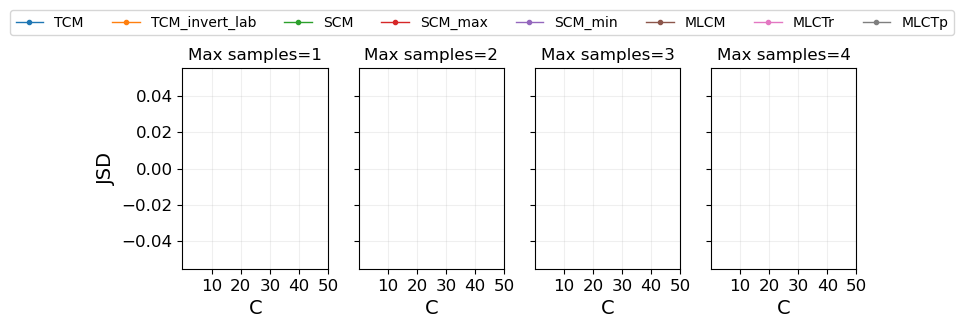

alpha: 0.1
soft: True


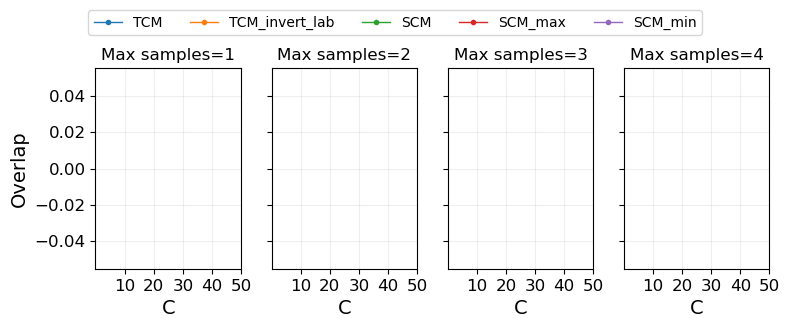

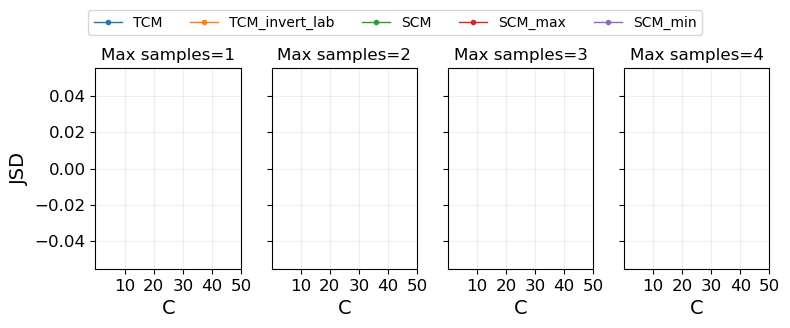

alpha: 0.2
soft: True


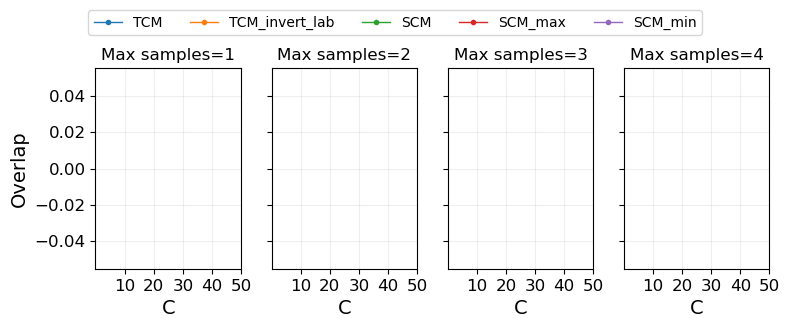

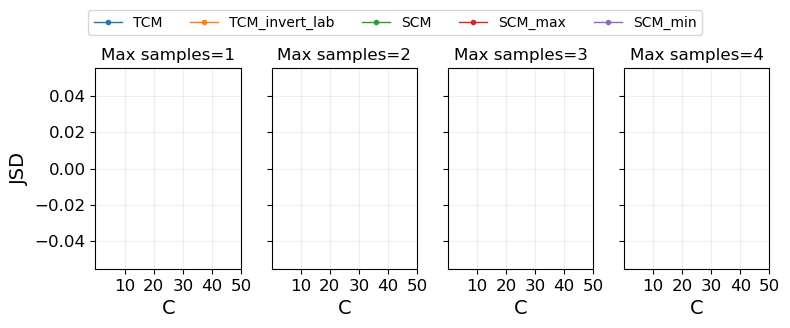

alpha: 0.4
soft: True


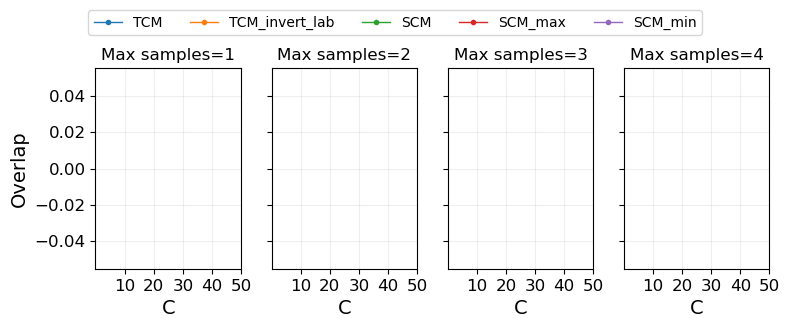

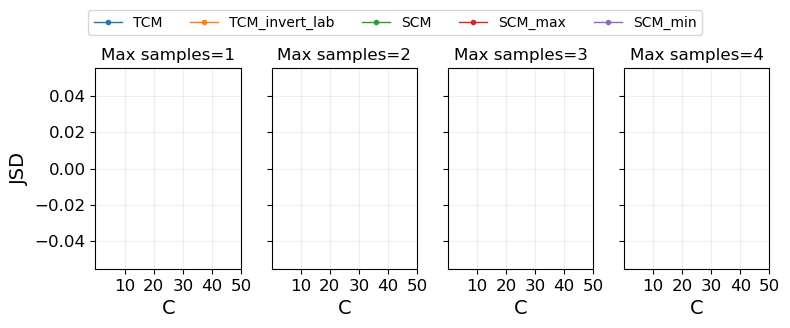

alpha: 0.8
soft: True


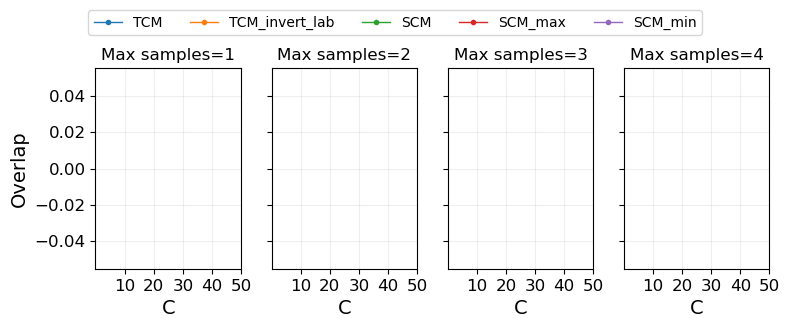

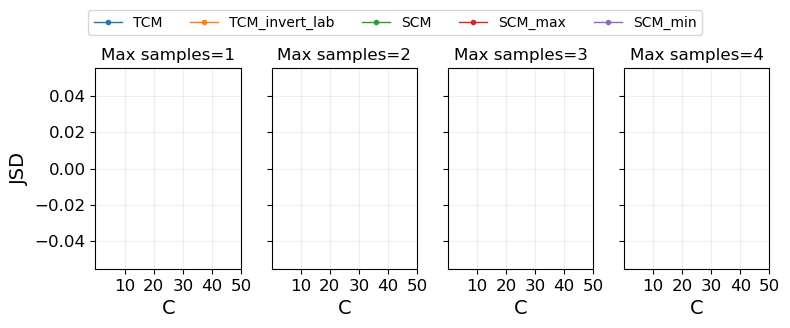

In [26]:
score_fns = {
    "Overlap": overlap,
    "JSD": jensen_shannon_divergence
}

alphas = [.1, .2, .4, .8]
n_modes = [1, 2, 3, 4]
C=[10, 20, 30, 40, 50]
N= 1
n_runs= 1
max_classes = 10

for soft in [False, True]:
    if soft:
        methods = ['TCM', 'TCM_invert_lab', 'SCM', 'SCM_max', 'SCM_min']
    else:
        methods = ['TCM', 'TCM_invert_lab', 'SCM', 'SCM_max', 'SCM_min', 'MLCM', 'MLCTr', 'MLCTp']
    
    for alpha in alphas:
        print("alpha:", alpha)
        print("soft:", soft)
        
        name = "plots2/synthetic_scores_"+str(alpha)+str(soft)+".png"
        plot_synthetic_scores(
            alpha=alpha,
            methods=methods,
            score_fns=score_fns,
            C=C,
            N= N,
            n_modes=n_modes,
            n_runs=n_runs,
            max_classes = max_classes,
            save_path=name,
            soft=False
        )